# Giraldo field-data error-diagnostic case study

## tl;dr

- The Giraldo data overlap the operational prediction period in **52 cells and 424 cell-years**, with 151 decline events from 2005–2021.
- In the matched subset, Logistic OISST-minus-trajectory macro within-year AP lift is **+0.0115** with a year-bootstrap 95% interval of **[-0.0140, +0.0426]**. Random Forest and XGBoost intervals also include zero.
- None of the 20 prespecified Logistic combinations of four ecological axes and five prediction diagnostics met the full stability rule.
- The result is an identification limit of a California-only, non-random, cross-scale field subset. It is not evidence that urchins, habitat, or kelp identity are ecologically unimportant.

Classification: pilot-informed exploratory diagnostic; not independent confirmation.

## Context & Methods

The primary 165-cell study estimates the incremental decision value of current canopy, canopy trajectory, and public NOAA proxies. This secondary case study does not add Giraldo field variables as a fifth coastwide prediction block. Instead, it asks whether field-observed ecological conditions explain recurrent out-of-fold errors or identify conditions where OISST improved annual risk rankings.

### Key Assumptions

- Field observations are aggregated from 60 m² transects to site-year medians and then to 10 km cell-year medians.
- A site-year is assigned to its nearest locked cell center when the Haversine distance is at most 7.2 km; 5 km is a strict sensitivity analysis.
- Risk ranks and top-20% monitoring selections are calculated in each full annual prediction cohort before the matched field subset is selected.
- Four axes were fixed before execution: urchin grazing pressure, rock probability, depth, and bull-versus-giant kelp contrast.
- Association estimates include region and year fixed effects with two-way cell/year cluster-robust intervals and within-outcome Benjamini–Hochberg adjustment.
- Field coverage is not representative of the full West Coast domain and is not imputed to unobserved cells or years.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'outputs').exists() and (ROOT.parent / 'outputs').exists():
    ROOT = ROOT.parent
RUN = ROOT / 'outputs/experiments/20260816_giraldo_error_case_study_v1'
assert (RUN / 'manifest.json').exists()

quality = pd.read_csv(RUN / 'data_quality_profile.csv')
coverage = pd.read_csv(RUN / 'cohort_coverage_by_region.csv')
performance = pd.read_csv(RUN / 'performance_summary.csv')
increments = pd.read_csv(RUN / 'performance_increment_summary.csv')
associations = pd.read_csv(RUN / 'ecological_axis_associations.csv')
support = pd.read_csv(RUN / 'condition_support_summary.csv')
repeated = pd.read_csv(RUN / 'repeated_error_cells.csv')
validation = pd.read_csv(RUN / 'validation_recheck.csv')
decision = json.loads((RUN / 'decision.json').read_text(encoding='utf-8'))

assert validation['passed'].all()
assert decision['stable_condition_count'] == 0
print('Loaded', RUN)
print('Independent checks passed:', int(validation['passed'].sum()), '/', len(validation))

Loaded /Users/miso/Documents/Codex/2026-06-11/create-an-initial-github-repository-structure/kelp-decline-early-warning/outputs/experiments/20260816_giraldo_error_case_study_v1
Independent checks passed: 25 / 25


## Data

In [2]:
quality

,metric,value
0,raw_field_rows,9728.000000
1,raw_field_columns,144.000000
2,raw_unique_sites,191.000000
3,raw_year_start,1999.000000
4,raw_year_end,2021.000000
5,raw_exact_duplicate_rows,3.000000
6,raw_coordinate_missing_rate,0.026624
7,unique_site_years,1745.000000
8,primary_matched_site_years,1624.000000
9,strict_matched_site_years,1308.000000


In [3]:
coverage[['region_group', 'full_cell_years', 'full_cells', 'matched_cell_years', 'matched_cells', 'matched_events', 'matched_cell_year_share']].round(3)

,region_group,full_cell_years,full_cells,matched_cell_years,matched_cells,matched_events,matched_cell_year_share
0,Baja California Norte,541,40,0,0,0,0.000
1,Baja California Sur,40,3,0,0,0,0.000
2,Central California,564,34,157,20,38,0.278
3,Northern California,135,16,35,7,18,0.259
4,Oregon,64,5,0,0,0,0.000
5,Southern California,735,52,232,25,95,0.316
6,Washington outer coast,236,15,0,0,0,0.000


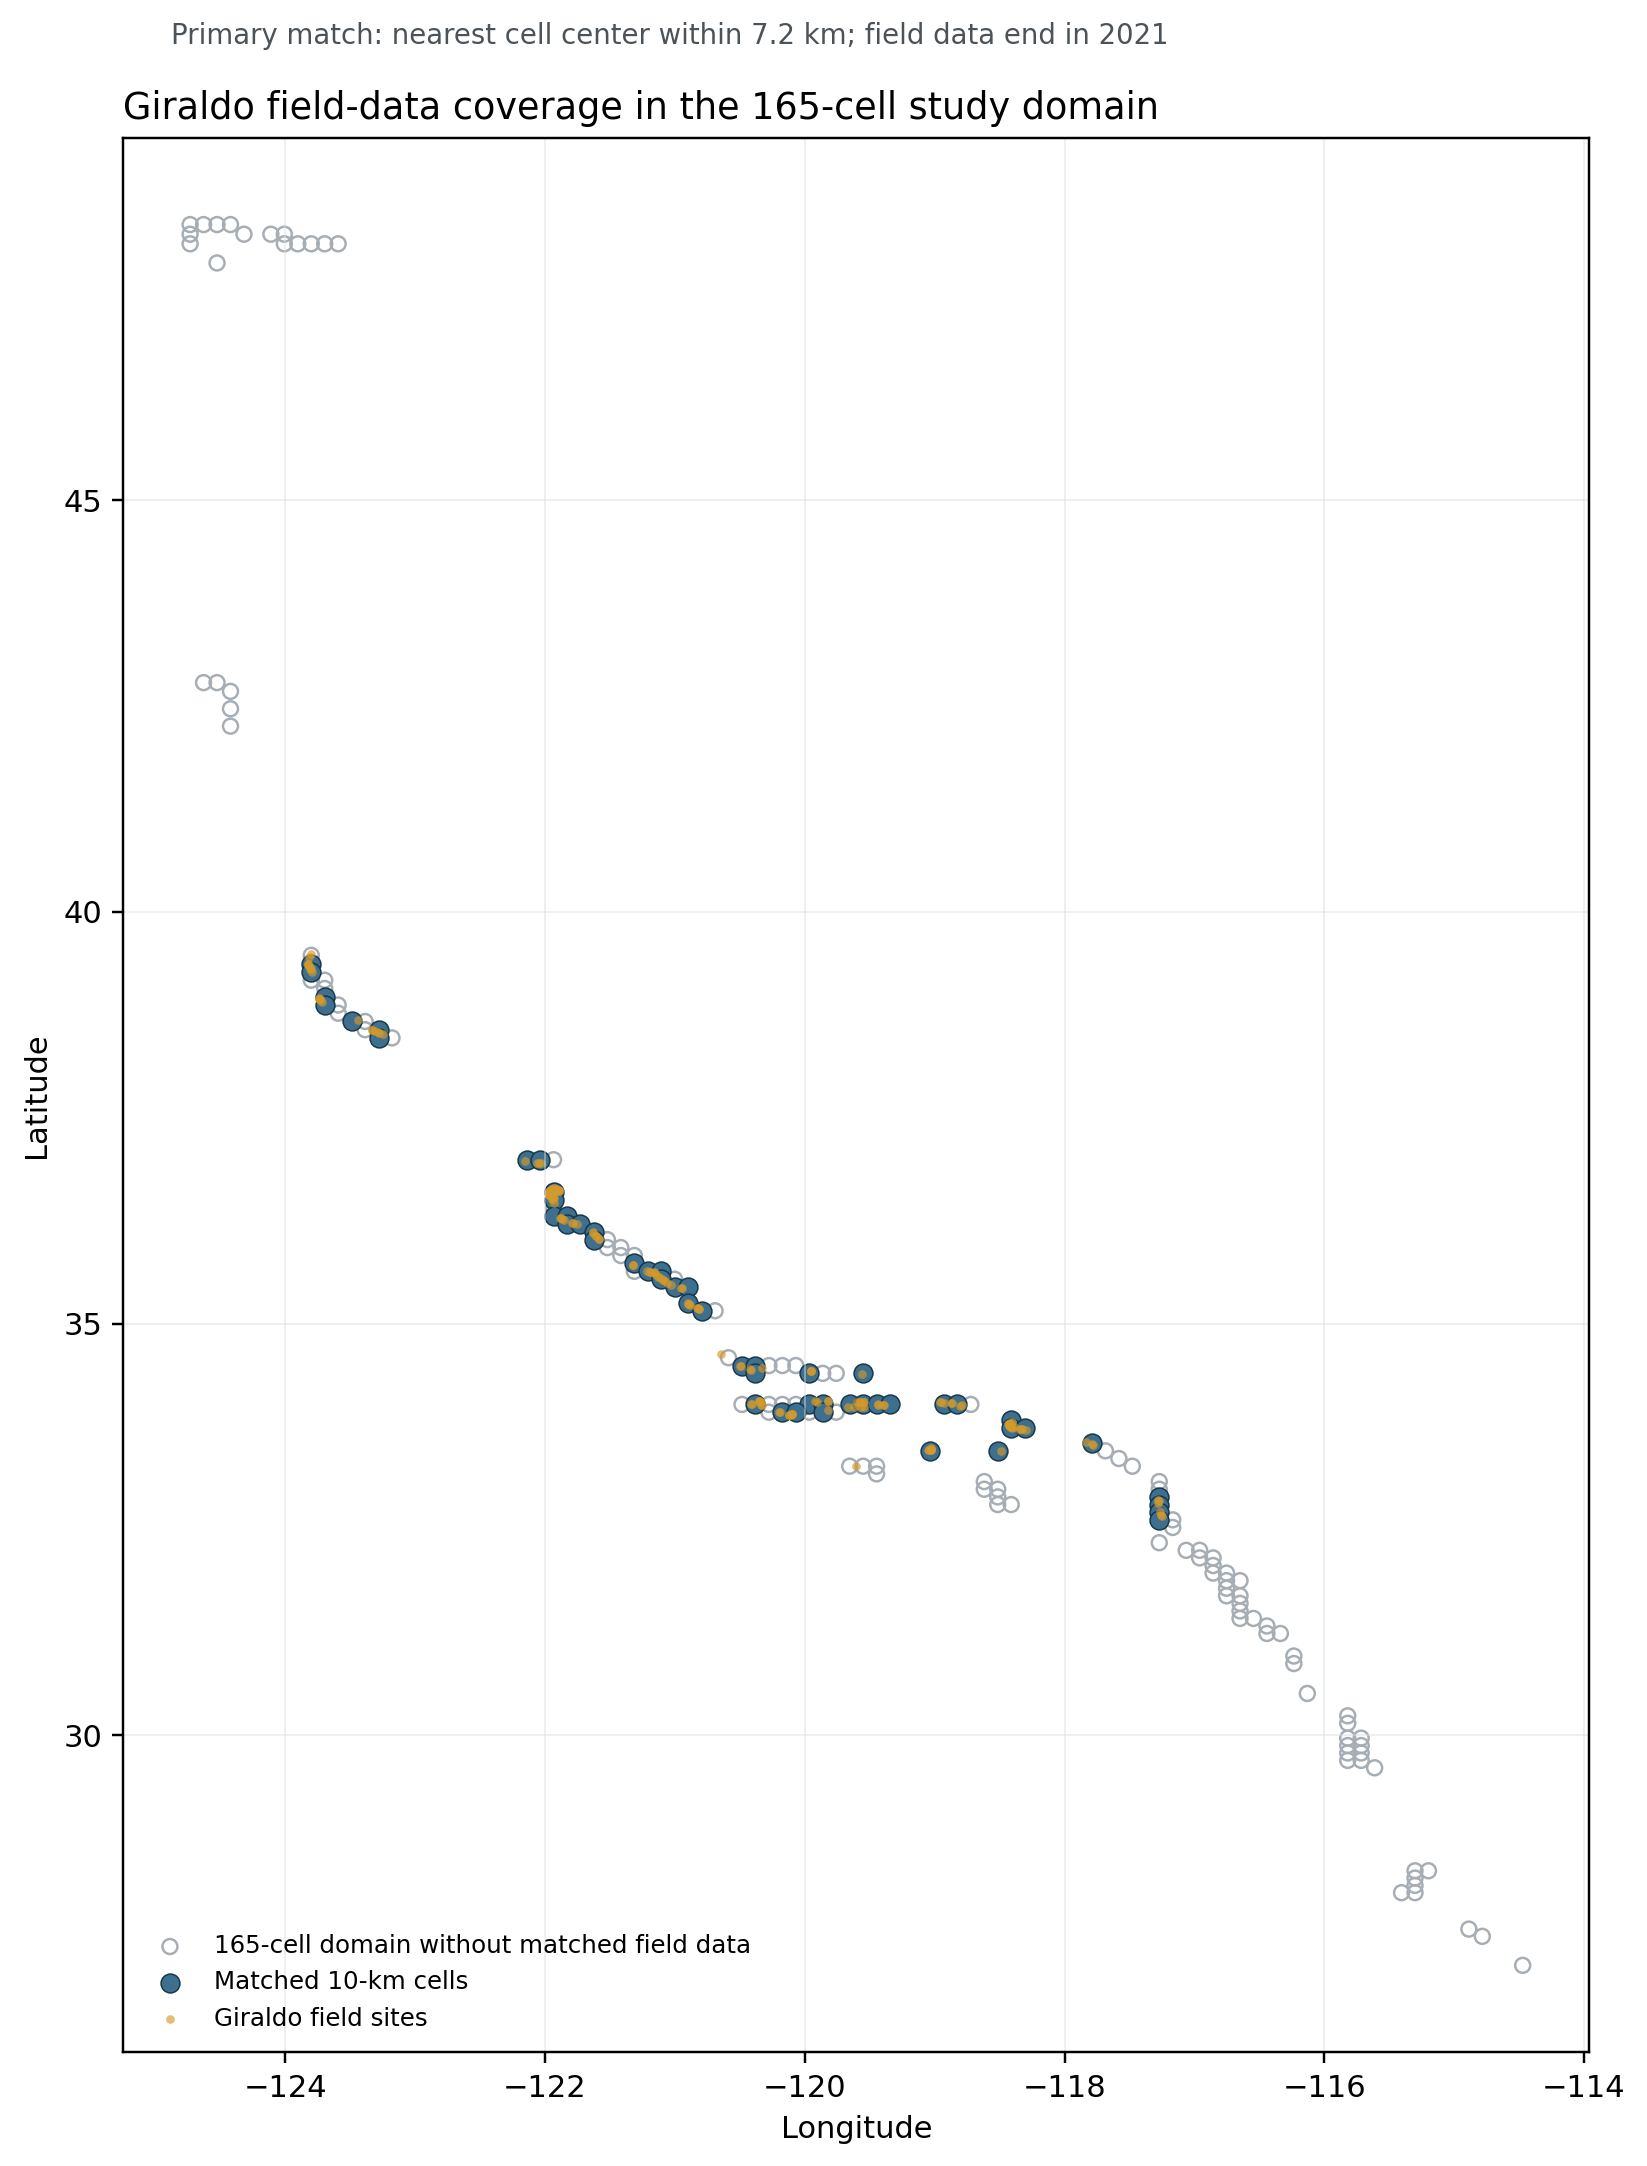

In [4]:
display(Image(filename=str(RUN / 'figure_01_field_coverage.png'), width=700))

The raw table contains 9,728 transect rows, 191 sites, and 23 survey years, but the operational error analysis contains 424 matched cell-years in 52 California cells. Northern California contributes only 35 cell-years, and Oregon, Washington, and Baja have no matched field observations. The matched data therefore serve as a diagnostic case, not an external-validation population.

## Results

### 1. Full-domain and matched-cohort performance

In [5]:
performance.loc[performance['model_family'].eq('logistic'), ['scope', 'feature_set', 'estimable_years', 'macro_within_year_ap_lift', 'ci_low', 'ci_high']].round(4)

,scope,feature_set,estimable_years,macro_within_year_ap_lift,ci_low,ci_high
0,full_165_domain,current_only,17,0.1909,0.1533,0.2277
1,full_165_domain,current_plus_trajectory,17,0.2076,0.1630,0.2547
2,full_165_domain,trajectory_plus_oisst,17,0.1883,0.1506,0.2244
9,giraldo_matched,current_only,16,0.2644,0.1625,0.3909
10,giraldo_matched,current_plus_trajectory,16,0.2980,0.1810,0.4390
11,giraldo_matched,trajectory_plus_oisst,16,0.3096,0.1882,0.4511


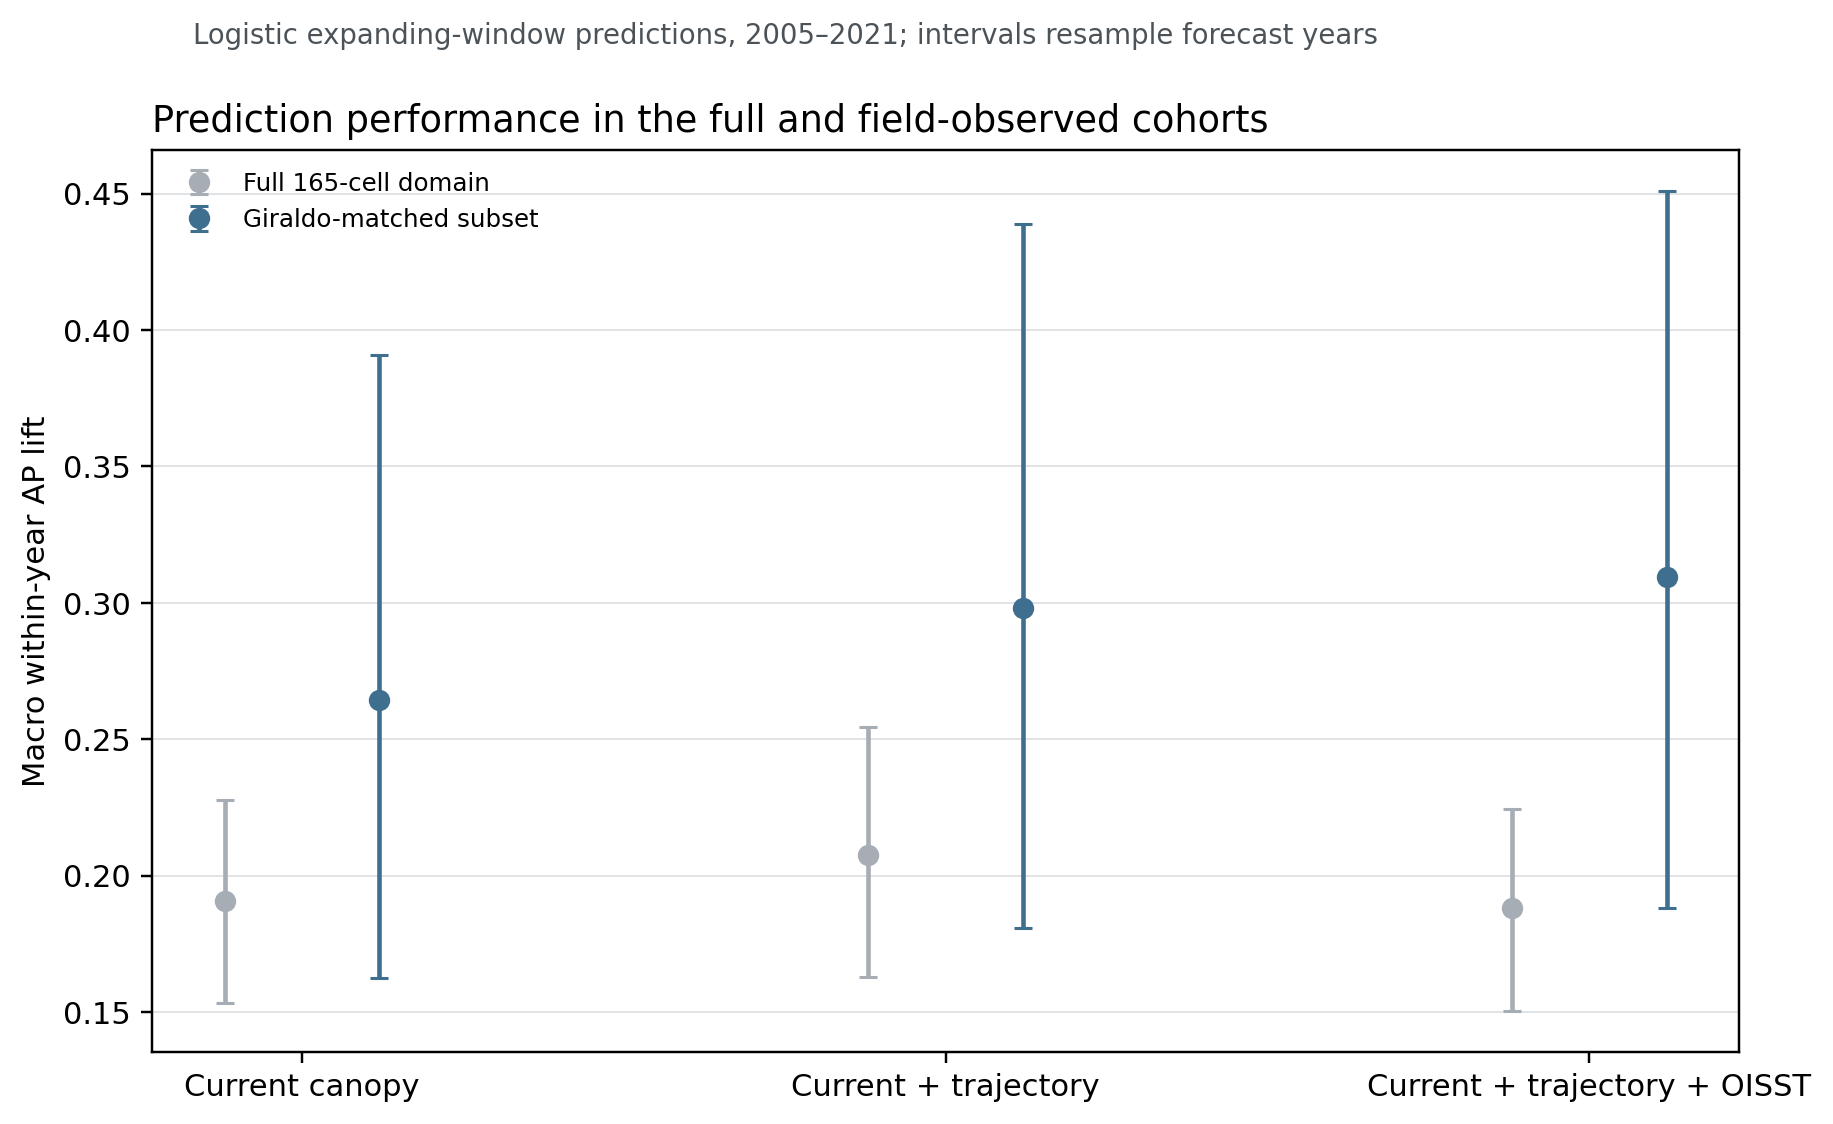

In [6]:
display(Image(filename=str(RUN / 'figure_04_matched_vs_full_performance.png'), width=760))

In [7]:
increments.loc[increments['scope'].eq('giraldo_matched'), ['model_family', 'comparison', 'paired_years', 'estimate', 'ci_low', 'ci_high']].round(4)

,model_family,comparison,paired_years,estimate,ci_low,ci_high
6,logistic,trajectory_minus_current,16,0.0336,-0.0341,0.1014
7,logistic,oisst_minus_trajectory,16,0.0115,-0.0140,0.0426
8,random_forest,trajectory_minus_current,16,0.0691,-0.0200,0.1551
9,random_forest,oisst_minus_trajectory,16,-0.0104,-0.0479,0.0236
10,xgboost,trajectory_minus_current,16,0.0510,-0.0233,0.1257
11,xgboost,oisst_minus_trajectory,16,0.0172,-0.0255,0.0595


The matched cohort shows higher absolute AP lift than the full domain, demonstrating selection rather than stronger generalizability. Within that matched cohort, OISST-minus-trajectory intervals include zero for all three model families. The subset therefore does not support a stable conditional OISST benefit.

### 2. Prespecified ecological-axis associations

In [8]:
primary = associations.loc[(associations['scope'].eq('primary_7p2km')) & (associations['model_family'].eq('logistic')), ['outcome_label', 'axis_label', 'n', 'estimate_per_sd', 'ci_low', 'ci_high', 'q_value', 'supported_bh']]
primary.round(4)

,outcome_label,axis_label,n,estimate_per_sd,ci_low,ci_high,q_value,supported_bh
0,Trajectory rank quality (pp),Urchin grazing pressure,424,1.1280,-2.4064,4.6624,0.7837,False
1,Trajectory rank quality (pp),Rock probability,424,-0.4940,-4.2453,3.2573,0.7837,False
2,Trajectory rank quality (pp),Depth,424,-0.4467,-3.7681,2.8748,0.7837,False
3,Trajectory rank quality (pp),Bull-vs-giant kelp contrast,424,-0.9118,-5.7366,3.9131,0.7837,False
4,False-negative probability,Urchin grazing pressure,151,0.0108,-0.0774,0.0991,0.7968,False
5,False-negative probability,Rock probability,151,0.0456,-0.0130,0.1042,0.2640,False
6,False-negative probability,Depth,151,0.0542,-0.0194,0.1277,0.2640,False
7,False-negative probability,Bull-vs-giant kelp contrast,151,0.0839,-0.0488,0.2166,0.2640,False
8,False-positive probability,Urchin grazing pressure,273,-0.0032,-0.0459,0.0395,0.8754,False
9,False-positive probability,Rock probability,273,0.0166,-0.0301,0.0632,0.7688,False


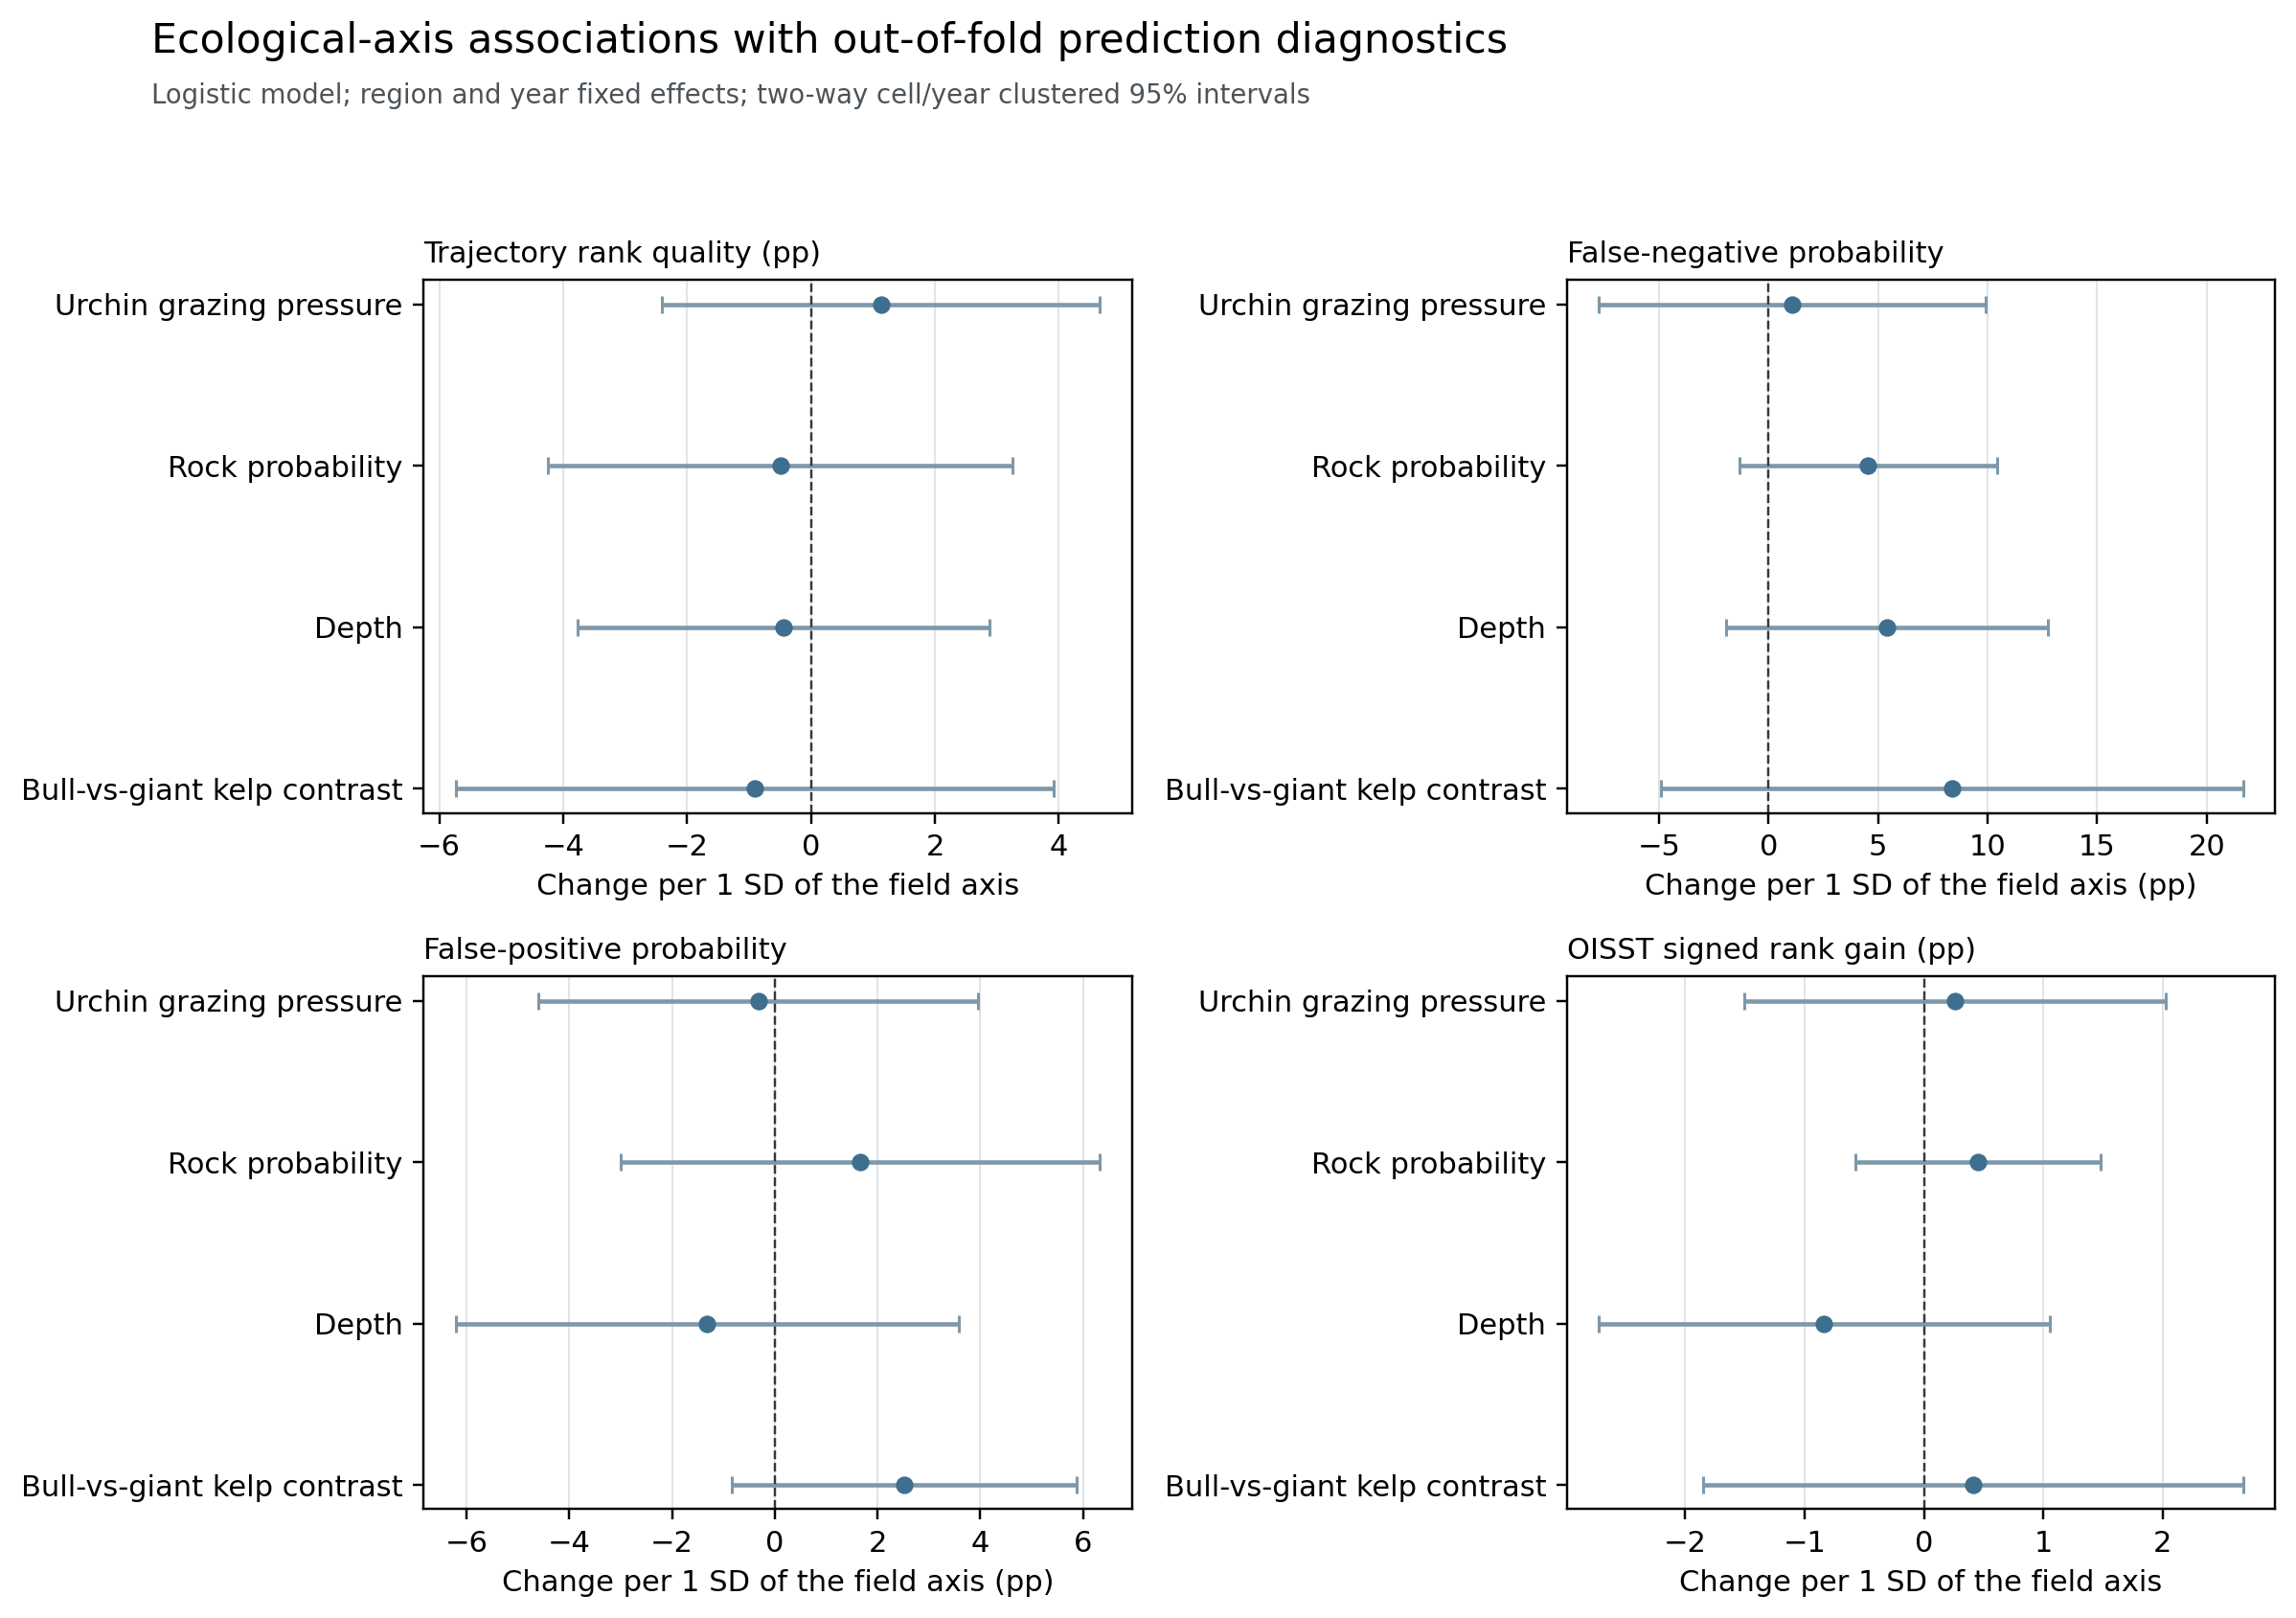

In [9]:
display(Image(filename=str(RUN / 'figure_02_primary_ecological_associations.png'), width=900))

In [10]:
support[['outcome', 'axis', 'primary_estimate_per_sd', 'primary_ci_low', 'primary_ci_high', 'primary_q_value', 'same_direction_model_count', 'strict_same_direction', 'stable_condition_supported']].round(4)

,outcome,axis,primary_estimate_per_sd,primary_ci_low,primary_ci_high,primary_q_value,same_direction_model_count,strict_same_direction,stable_condition_supported
0,trajectory_rank_quality_pp,grazing_log1p,1.1280,-2.4064,4.6624,0.7837,2,True,False
1,trajectory_rank_quality_pp,rock_probability,-0.4940,-4.2453,3.2573,0.7837,1,True,False
2,trajectory_rank_quality_pp,depth_m,-0.4467,-3.7681,2.8748,0.7837,2,True,False
3,trajectory_rank_quality_pp,kelp_species_contrast,-0.9118,-5.7366,3.9131,0.7837,3,True,False
4,trajectory_false_negative,grazing_log1p,0.0108,-0.0774,0.0991,0.7968,1,False,False
5,trajectory_false_negative,rock_probability,0.0456,-0.0130,0.1042,0.2640,3,True,False
6,trajectory_false_negative,depth_m,0.0542,-0.0194,0.1277,0.2640,3,True,False
7,trajectory_false_negative,kelp_species_contrast,0.0839,-0.0488,0.2166,0.2640,3,True,False
8,trajectory_false_positive,grazing_log1p,-0.0032,-0.0459,0.0395,0.8754,3,True,False
9,trajectory_false_positive,rock_probability,0.0166,-0.0301,0.0632,0.7688,2,True,False


No prespecified combination satisfies all four requirements: an interval excluding zero, q < 0.10, the same direction in at least two model families, and the same direction under the strict 5-km match. This does not establish zero ecological effect; it means the available partial and cross-scale observations do not identify a stable failure condition.

### 3. Recurrent error cells

In [11]:
repeated.loc[repeated['event_opportunities'].ge(3), ['cell_id', 'region_group', 'observed_years', 'event_opportunities', 'trajectory_false_negatives', 'trajectory_false_negative_rate', 'trajectory_false_positives', 'trajectory_false_positive_rate', 'mean_grazing_log1p']].sort_values(['trajectory_false_negative_rate', 'event_opportunities'], ascending=[False, False]).head(15).round(3)

,cell_id,region_group,observed_years,event_opportunities,trajectory_false_negatives,trajectory_false_negative_rate,trajectory_false_positives,trajectory_false_positive_rate,mean_grazing_log1p
31,westcoast_0167,Southern California,14,7,7,1.000,0,0.000,5.838
42,westcoast_0186,Southern California,13,6,6,1.000,0,0.000,2.140
10,westcoast_0110,Central California,17,5,5,1.000,1,0.083,3.011
40,westcoast_0181,Southern California,11,5,5,1.000,1,0.167,4.109
41,westcoast_0183,Southern California,14,5,5,1.000,0,0.000,5.400
44,westcoast_0188,Southern California,11,4,4,1.000,1,0.143,2.193
9,westcoast_0108,Central California,17,3,3,1.000,0,0.000,2.893
16,westcoast_0118,Central California,7,3,3,1.000,0,0.000,0.000
37,westcoast_0175,Southern California,7,3,3,1.000,0,0.000,5.444
50,westcoast_0227,Southern California,4,3,3,1.000,0,0.000,0.634


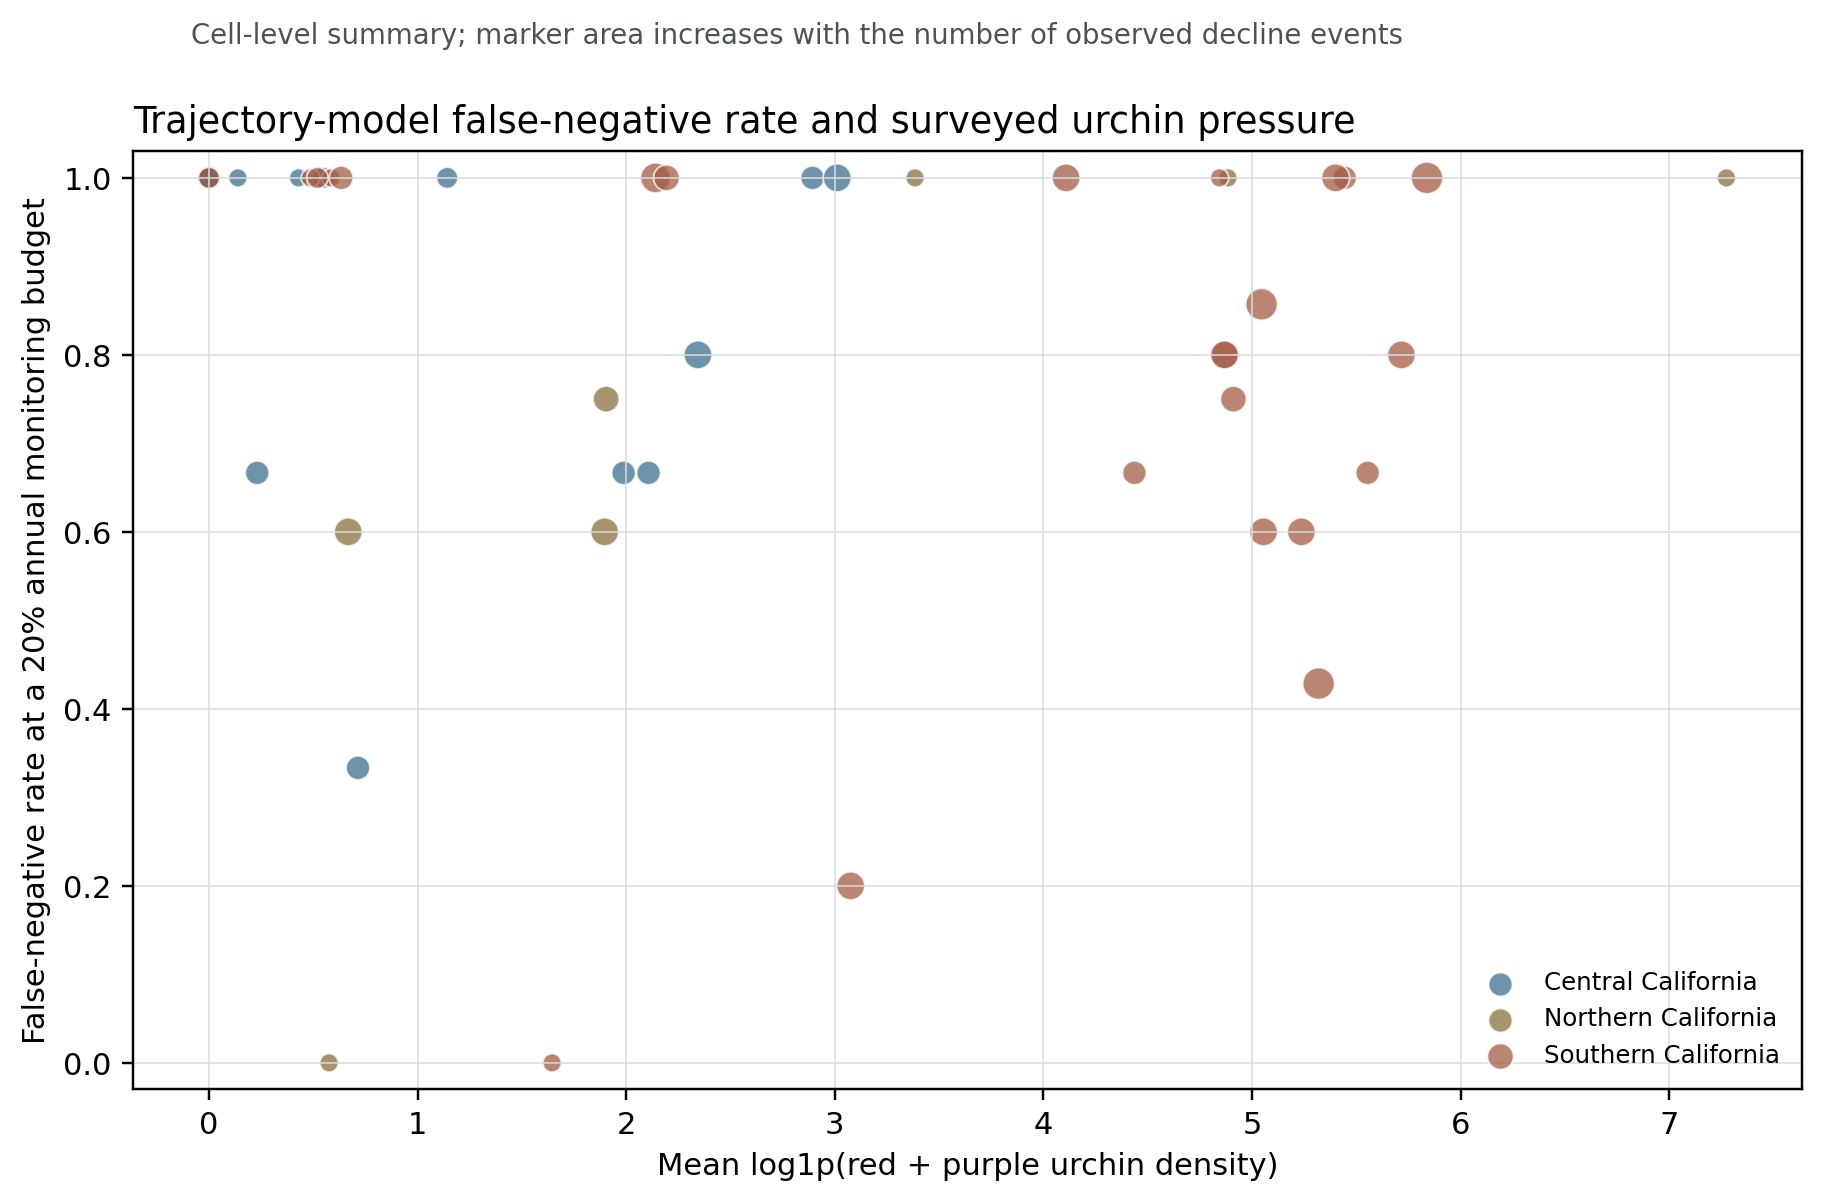

In [12]:
display(Image(filename=str(RUN / 'figure_03_recurrent_miss_vs_grazing.png'), width=760))

Several cells are repeatedly missed at a 20% annual monitoring budget, but those misses are not monotonically concentrated along the surveyed urchin-pressure axis after region and year are considered. Recurrent-error maps are still useful for designing new standardized field surveys, but not as evidence that the present Giraldo axes can repair the coastwide predictor.

## Takeaways

1. Keep Giraldo as a California-only ecological error diagnostic, not information block B5.
2. The matched field cohort is selected and has different apparent performance from the full domain.
3. The four fixed ecological axes do not reveal a robust condition where OISST becomes valuable or trajectory errors recur.
4. The defensible paper claim is that neither the average analysis nor this limited conditional diagnostic supports operational incremental value for the tested public proxy block.
5. A stronger test requires standardized biological sampling targeted to recurrent-error and comparison cells at a spatial support closer to the decision unit.